<a href="https://colab.research.google.com/github/fadlurrahmanh/Pemodelan-dan-Simulasi---Simulasi-Penyebaran-COVID/blob/main/Pemodelan_dan_Simulasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SIMULASI PENYEBARAN COVID
Penyebaran COVID-19 dapat dipandang sebagai sistem dinamis kontinu karena jumlah individu rentan, terinfeksi, dan sembuh berubah terhadap waktu.

Pada proyek ini digunakan **model SIR (Susceptible-Infected-Recovered)** untuk merepresentasikan proses penularan penyakit.

Tujuan:
1. Memodelkan penyebaran COVID-19 dengan persamaan diferensial
2. Menyelesaikan model menggunakan metode Runge-Kutta Orde 4 (RK4)
3. Membandingkan hasil simulasi dengan data nyata


**1. Import Library**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


**2. Dataset**

Data diambil dari Johns Hopkins University COVID-19 Time Series.

Data diolah menjadi:
- S(t) : populasi rentan
- I(t) : kasus aktif
- R(t) : sembuh + meninggal

I = Confirmed − Recovered − Deaths  
R = Recovered + Deaths  
S = N − I − R


In [4]:
confirmed = pd.read_csv("time_series_covid19_confirmed_global.csv")
recovered = pd.read_csv("time_series_covid19_recovered_global.csv")
deaths = pd.read_csv("time_series_covid19_deaths_global.csv")

country = "Indonesia"

c = confirmed[confirmed['Country/Region']==country].iloc[:,4:].sum()
r = recovered[recovered['Country/Region']==country].iloc[:,4:].sum()
d = deaths[deaths['Country/Region']==country].iloc[:,4:].sum()

**3. Hitung SIR Dari Data**

Model SIR dinyatakan dengan persamaan diferensial:

dS/dt = −βSI/N  
dI/dt = βSI/N − γI  
dR/dt = γI

β : laju penularan  
γ : laju pemulihan  
N : total populasi


In [5]:
I_real = c - r - d
R_real = r + d
N = 273_000_000
S_real = N - I_real - R_real

t = np.arange(len(I_real))
S_real = S_real.values
I_real = I_real.values
R_real = R_real.values

**4. EDA Visualisasi Data Nyata**

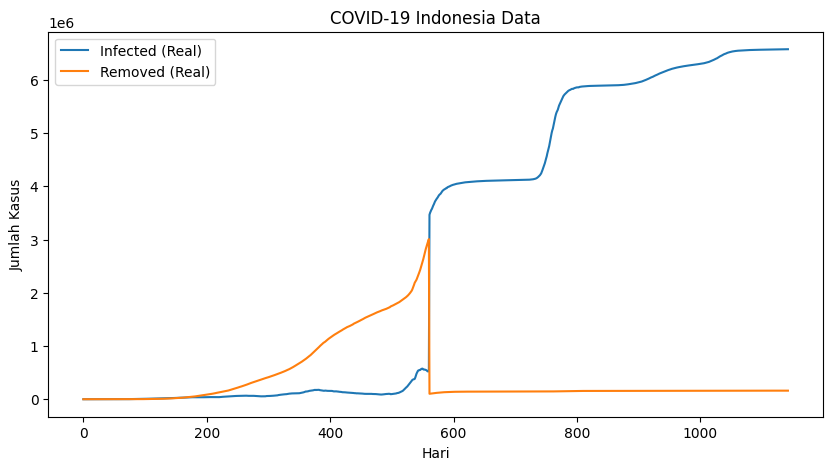

In [6]:
plt.figure(figsize=(10,5))
plt.plot(t, I_real, label="Infected (Real)")
plt.plot(t, R_real, label="Removed (Real)")
plt.legend()
plt.title("COVID-19 Indonesia Data")
plt.xlabel("Hari")
plt.ylabel("Jumlah Kasus")
plt.show()

**5. Model SIR**

In [7]:
def sir_model(t, y, beta, gamma, N):
    S, I, R = y
    dSdt = -beta*S*I/N
    dIdt = beta*S*I/N - gamma*I
    dRdt = gamma*I
    return np.array([dSdt, dIdt, dRdt])

**6. RK Solver**

In [8]:
def rk4_solver(beta, gamma):
    y = np.zeros((len(t),3))
    y[0] = [S_real[0], I_real[0], R_real[0]]
    dt = 1

    for i in range(len(t)-1):
        k1 = sir_model(t[i], y[i], beta, gamma, N)
        k2 = sir_model(t[i]+dt/2, y[i]+dt*k1/2, beta, gamma, N)
        k3 = sir_model(t[i]+dt/2, y[i]+dt*k2/2, beta, gamma, N)
        k4 = sir_model(t[i]+dt, y[i]+dt*k3, beta, gamma, N)

        y[i+1] = y[i] + dt*(k1+2*k2+2*k3+k4)/6
    return y

**7. Fitting Prameter**

Parameter β dan γ dicari dengan meminimalkan selisih antara data infeksi nyata dan hasil simulasi model menggunakan optimisasi (least error).


In [9]:
def loss(params):
    beta, gamma = params
    pred = rk4_solver(beta, gamma)
    I_pred = pred[:,1]
    return np.mean((I_real - I_pred)**2)

result = minimize(loss, [0.3,0.1], bounds=[(0.0001,1),(0.0001,1)])
beta_opt, gamma_opt = result.x
print("Beta:", beta_opt)
print("Gamma:", gamma_opt)

Beta: 0.3
Gamma: 0.1


**8. Simulasi Final**

Grafik menunjukkan perbandingan antara data aktual dan hasil model.

Jika kurva mendekati data nyata maka model mampu merepresentasikan dinamika penyebaran penyakit.


In [10]:
sim = rk4_solver(beta_opt, gamma_opt)
S_pred, I_pred, R_pred = sim[:,0], sim[:,1], sim[:,2]

**9. Visualisasi Model VS Data**

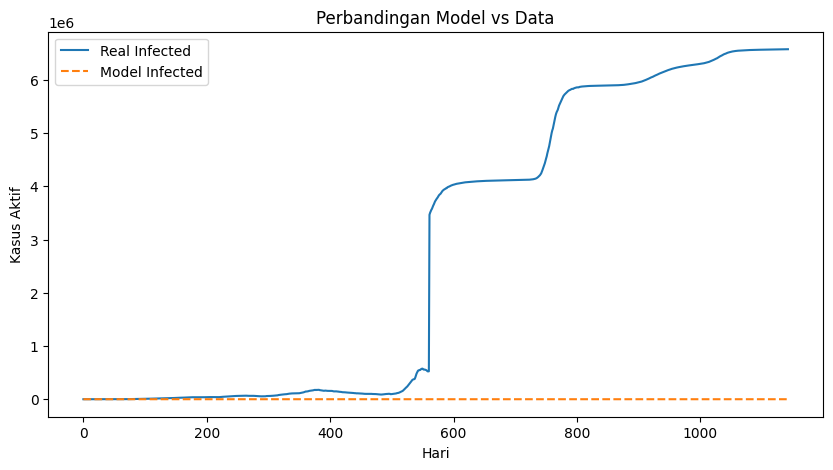

In [11]:
plt.figure(figsize=(10,5))
plt.plot(t, I_real, label="Real Infected")
plt.plot(t, I_pred, '--', label="Model Infected")
plt.legend()
plt.title("Perbandingan Model vs Data")
plt.xlabel("Hari")
plt.ylabel("Kasus Aktif")
plt.show()

**10. Plot SIR Model**


Model SIR dengan metode RK4 dapat menggambarkan pola penyebaran COVID-19 secara cukup baik.

Perbedaan yang muncul disebabkan oleh faktor nyata seperti kebijakan pemerintah, vaksinasi, dan perilaku masyarakat yang tidak dimasukkan dalam model sederhana.


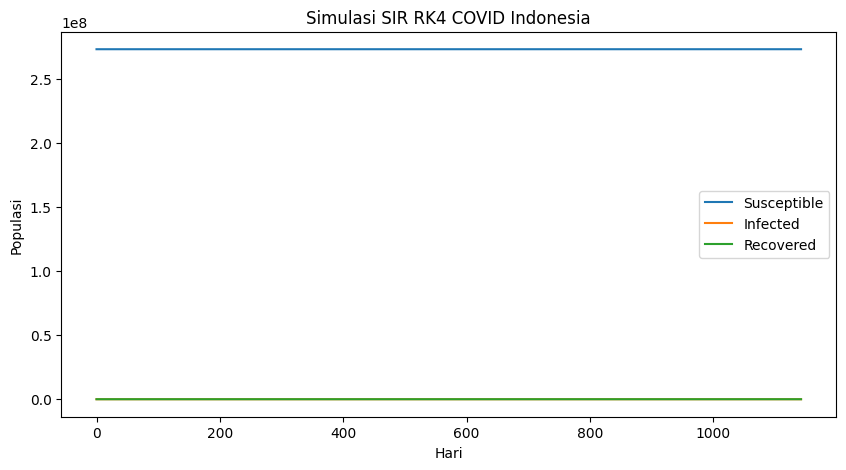

In [12]:
plt.figure(figsize=(10,5))
plt.plot(t, S_pred, label='Susceptible')
plt.plot(t, I_pred, label='Infected')
plt.plot(t, R_pred, label='Recovered')
plt.legend()
plt.title('Simulasi SIR RK4 COVID Indonesia')
plt.xlabel('Hari')
plt.ylabel('Populasi')
plt.show()